# 整数長ジョブシーケンス問題

こちらでは、[Lucas, 2014, "Ising formulations of many NP problems"](https://doi.org/10.3389/fphy.2014.00005)の 6.3. Job Sequencing with Integer Lengths を OpenJij と [JijModeling](https://jij-inc-jijmodeling-tutorials-ja.readthedocs-hosted.com/ja/latest/introduction.html)、そして ommx-openjij-adapter を用いて解く方法をご紹介します。

## 概要: 整数長ジョブシーケンス問題とは

タスク1は実行するのに1時間、タスク2は実行に3時間、というように、整数の長さを持つタスクがいくつかあったとします。
これらを複数の実行するコンピュータに配分するとき、偏りを作ることなくコンピュータの実行時間を分散させるにはどのような組合せがあるでしょうか、というのを考える問題です。

### 具体例

分かりやすくするために具体的に以下のような状況を考えてみましょう。 

> ここに10個のタスクと3個のコンピュータがあります。10個の仕事の長さはそれぞれ$1, 2, \dots, 10$とします。
> これらのタスクをどのようにコンピュータに仕事を割り振れば仕事にかかる時間の最大値を最小化できるか考えます。
> この場合、例えば1つ目のコンピュータには9, 10、2つ目には1, 2, 7, 8、3つ目には3, 4, 5, 6とするととなり、3つのコンピュータの実行時間の最大値は19となり、これが最適解です。

![](../../../assets/integer_jobs_01.png)

### 問題の一般化

$N$個のタスク$\{0, 1, \dots, N-1\}$と$M$個のコンピュータ$\{0, 1, \dots, M-1\}$を考えましょう。各タスクの実行にかかる時間のリストを$L = \{L_0, L_1, \dots, L_{N-1}\}$とします。
$j$番目のコンピュータで実行される仕事の集合を$V_j$としたとき、コンピュータ$j$でタスクを終えるまでの時間は$A_j = \sum_{i \in V_j} L_i$となります。
$i$番目のタスクをコンピュータ$j$で行うことを表すバイナリ変数を$x_{i, j}$とします。

**制約: タスクはどれか1つのコンピュータで実行されなければならない**

例えば、タスク3をコンピュータ1と2の両方で実行することは許されません。これを数式にすると

$$
\sum_{j=0}^{M-1} x_{i, j} = 1 \quad (\forall i \in \{ 0, 1, \dots, N-1 \})
\tag{1}
$$

**目的関数: コンピュータ0の実行時間と他の実行時間の差を小さくする**

コンピュータ0の実行時間を基準とし、それと他のコンピュータの実行時間の差を最小にすることを考えます。これにより実行時間のばらつきが抑えられ、タスクが分散されるようになります。

$$
\min\left\{ \sum_{j=1}^{M-1} (A_0 -A_j)^2\right\} 
\tag{2}
$$

## JijModelingによる定式化

次に、JijModelingを使って上記の数理モデルを定式化してみましょう。まずは、数理モデルに現れる変数およびパラメーターを定義します。

In [1]:
import jijmodeling as jm

problem = jm.Problem('Integer Jobs')

L = problem.Float('L', ndim=1)
N = problem.DependentVar("N", L.len_at(0))
M = problem.Natural('M')
x = problem.BinaryVar('x', shape=(N, M))

`L`は各タスクの実行時間を表す1次元配列です。
`N`はタスク数を表します。
`M`はコンピュータの数を表します。
そして、$x$は2次元のバイナリ変数列を表します。

### 制約

式(1)の制約を定式化しましょう。

In [2]:
# set constraint: job must be executed using a certain node
problem += problem.Constraint('onehot', lambda i: jm.sum(M, lambda j: x[i, j]) == 1, domain=N)

### 目的関数

次に、式(2)の目的関数を定式化しましょう。

In [3]:
# set objective function: minimize difference between node 0 and others
A_0 = jm.sum(N, lambda i: L[i]*x[i, 0])
problem += jm.sum(
    jm.filter(lambda j: j != 0, M),
    lambda j: (A_0 - jm.sum(N, lambda i: L[i]*x[i, j])) ** 2,
)

`jm.filter(lambda j: j != 0, M)` は$j \neq 0$の$j$を取ることを意味します。

定式化した数式をJupyter Notebookで表示してみましょう。

In [4]:
problem

Problem(name="Integer Jobs", sense=MINIMIZE, objective=sum(M.filter(lambda j: j != 0).map(lambda (j: natural): (sum(N.map(lambda (i: natural): L[i] * x[i, 0])) - sum(N.map(lambda (i: natural): L[i] * x[i, j]))) ** 2)), constraints={onehot: [Constraint(name="onehot", , lambda i: sum(M.map(lambda (j: natural): x[i, j])) == 1, domain=set(N)),],})

## インスタンスの作成

インスタンスデータを以下のようにします。

In [5]:
# set a list of jobs
inst_L = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# set the number of Nodes
inst_M = 3
instance_data = {'L': inst_L, 'M': inst_M}

先程の具体例と同様に、$\{1, 2, \dots, 10\}$の10個のタスクを、3台のコンピュータに分散させる状況を考えます。

## OpenJijによる最適化計算の実行

OpenJijのシミュレーテッド・アニーリングを用いて、最適化問題を解いてみましょう。

In [6]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(
    instance, num_reads=100, uniform_penalty_weight=8.0, beta_max=100
).best_feasible_unrelaxed

## 解の可視化

最後に、得られた解を可視化しましょう。

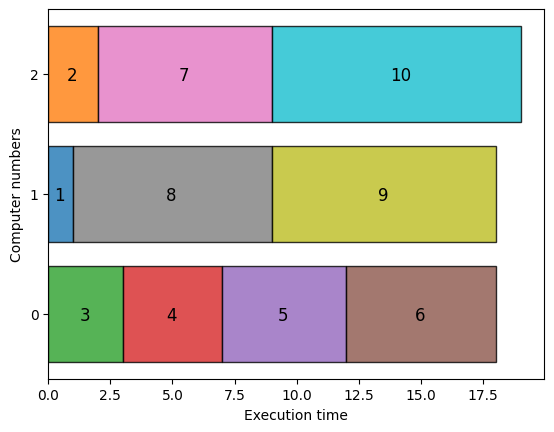

In [7]:
import matplotlib.pyplot as plt
import numpy as np

df = best_sample.decision_variables_df
x_indices = df[(df["name"] == "x") & (df["value"] > 0.5)]["subscripts"].to_list()
# get the instance information
L = instance_data["L"]
M = instance_data["M"]
# initialize execution time
exec_time = np.zeros(M, dtype=np.int64)
# compute summation of execution time each nodes
for i, j in x_indices:
    plt.barh(j, L[i], left=exec_time[j],ec="k", linewidth=1,alpha=0.8)
    plt.text(exec_time[j] + L[i] / 2.0 - 0.25 ,j-0.05, str(i+1),fontsize=12)
    exec_time[j] += L[i]
plt.yticks(range(M))
plt.ylabel('Computer numbers')
plt.xlabel('Execution time')
plt.show()

可視化されたグラフから、実行時間が3台のコンピュータに分散されていることがわかります。 この場合の実行時間の最大値は19であることから、最適解が得られていることもわかります。3つのコンピュータの実行時間がほぼ均等な解が得られました。